#LORENZO SANSONE 0001121128
#lorenzo.sansone3@studio.unibo.it

# Sentence Reconstruction

The purpose of this project is to take in input a sequence of words corresponding to a random permutation of a given english sentence, and reconstruct the original sentence.

The output can be either produced in a single shot, or through an iterative (autoregressive) loop generating a single token at a time.


CONSTRAINTS:
* No pretrained model can be used.
* The neural network models should have less the 20M parameters.
* No postprocessing should be done (e.g. no beamsearch)
* You cannot use additional training data.


BONUS PARAMETERS:

A bonus of 0-2 points will be attributed to incentivate the adoption of models with a low number of parameters.

# Dataset

The dataset is composed by sentences taken from the generics_kb dataset of hugging face. We restricted the vocabolary to the 10K most frequent words, and only took sentences making use of this vocabulary.

In [1]:
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.31.0, but you have requests 2.32.3 which is incompatible.


In [2]:
!pip install keras-nlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 49.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.8/589.8 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 41.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.2/311.2 kB 16.1 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: h5py
    Found existing installation: h5py 3.9.0
    Uninstalling h5py-3.9.0:
      Suc

Download the dataset

In [3]:
from datasets import load_dataset
from keras.layers import TextVectorization
import tensorflow as tf
import numpy as np
np.random.seed(42)
ds = load_dataset('generics_kb',trust_remote_code=True)['train']

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/1020868 [00:00<?, ? examples/s]

Filter row with length greater than 8.


In [4]:
ds = ds.filter(lambda row: len(row["generic_sentence"].split(" "))>8 )
corpus = [ '<start> ' + row['generic_sentence'].replace(","," <comma>") + ' <end>' for row in ds ]
corpus = np.array(corpus)


Filter:   0%|          | 0/1020868 [00:00<?, ? examples/s]

Create a tokenizer and Detokenizer

In [5]:
tokenizer=TextVectorization( max_tokens=10000, standardize="lower_and_strip_punctuation", encoding="utf-8",) #con il max prende le piu frequenti. ordina i token del vocab dal piu frequente al meno frequente
tokenizer.adapt(corpus)

class TextDetokenizer:
    def __init__(self, vectorize_layer):
        self.vectorize_layer = vectorize_layer
        vocab = self.vectorize_layer.get_vocabulary()
        self.index_to_word = {index: word for index, word in enumerate(vocab)}

    def __detokenize_tokens(self, tokens):
        def check_token(t):
          if t == 3:
            s="<start>"
          elif t ==2:
            s="<end>"
          elif t ==7:
            s="<comma>"
          else:
            s=self.index_to_word.get(t, '[UNK]')
          return s

        return ' '.join([ check_token(token) for token in tokens if token != 0])

    def __call__(self, batch_tokens):
        return [self.__detokenize_tokens(tokens) for tokens in batch_tokens]



detokenizer = TextDetokenizer( tokenizer )
sentences = tokenizer( corpus ).numpy()


Remove from corpus the sentences where any unknow word appears

In [6]:
mask = np.sum( (sentences==1) , axis=1) >= 1
original_data = np.delete( sentences, mask , axis=0)

In [7]:
original_data.shape

(241236, 28)

Shuffle the sentences

In [8]:
from tensorflow.keras.utils import Sequence

class DataGenerator(Sequence):
    def __init__(self, data, batch_size=32, shuffle=True):

        self.data = data
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        data_batch = np.array([self.data[k] for k in indexes])
        #cop of ordered sequences
        result = np.copy(data_batch)
        #shuffle only the relevant positions for each batch
        for i in range(data_batch.shape[0]):
          np.random.shuffle(data_batch[i,1:data_batch[i].argmin() - 1])

        return data_batch , result

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.data))
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [9]:
# Make a random permutation of training and test set
np.random.seed(42)
# Shuffle the all data
shuffled_indices = np.random.permutation(len(original_data))
shuffled_data = original_data[shuffled_indices]

In [10]:
train_generator = DataGenerator(shuffled_data[:220000])
val_generator = DataGenerator(shuffled_data[220000:238000])
test_generator  = DataGenerator(shuffled_data[238000:])

In [11]:
generator_data = DataGenerator(original_data)
sfuffle_i, orig_i = generator_data.__getitem__(1)

In [12]:
sfuffle_i= detokenizer(sfuffle_i)
orig_i = detokenizer(orig_i)

for i in range(7):
  print("original phrase: ", orig_i[i])
  print("shuffled phrase: ", sfuffle_i[i])
  print()

original phrase:  <start> history indicates that power has been controlled by men <end>
shuffled phrase:  <start> that has power indicates by controlled history been men <end>

original phrase:  <start> insurance companies owned by tobacco companies charge smokers nearly double for term life insurance <end>
shuffled phrase:  <start> smokers double term for companies life tobacco owned insurance by nearly charge insurance companies <end>

original phrase:  <start> hair styles vary with age <comma> and with ethnic identity <end>
shuffled phrase:  <start> with ethnic <comma> with age identity hair and vary styles <end>

original phrase:  <start> temperatures vary more between day and night and high and low altitudes than between seasons <end>
shuffled phrase:  <start> vary than high and and night seasons between temperatures altitudes more low and between day <end>

original phrase:  <start> most pesticides have ingredients that affect the nervous system of insects <end>
shuffled phrase: 

In [13]:
#detokenizer(y)[0:7]

In [14]:
"""
original_data = [sen for sen in tokenizer.texts_to_sequences(corpus) if (len(sen) <= 32 and len(sen)>4 and not(1 in sen))]

if dump:
    with open('original.pickle', 'wb') as handle:
        pickle.dump(original_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

print ("filtered sentences: ",len(original_data))

sos = tokenizer.word_index['<start>']
eos = tokenizer.word_index['<end>']

tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'
"""

'\noriginal_data = [sen for sen in tokenizer.texts_to_sequences(corpus) if (len(sen) <= 32 and len(sen)>4 and not(1 in sen))]\n\nif dump:\n    with open(\'original.pickle\', \'wb\') as handle:\n        pickle.dump(original_data, handle, protocol=pickle.HIGHEST_PROTOCOL)\n\nprint ("filtered sentences: ",len(original_data))\n\nsos = tokenizer.word_index[\'<start>\']\neos = tokenizer.word_index[\'<end>\']\n\ntokenizer.word_index[\'<pad>\'] = 0\ntokenizer.index_word[0] = \'<pad>\'\n'

# Metrics

Let s be the source string and p your prediction. The quality of the results will be measured according to the following metric:

1.  look for the longest substring w between s and p
2.  compute |w|/max(|s|,|p|)

If the match is exact, the score is 1.

When computing the score, you should NOT consider the start and end tokens.



The longest common substring can be computed with the SequenceMatcher function of difflib, that allows a simple definition of our metric.

In [13]:
from difflib import SequenceMatcher

def score(s,p):
  match = SequenceMatcher(None, s, p).find_longest_match()
  #print(match.size)
  return (match.size/max(len(p),len(s)))

Let's do an example.

In [14]:
original = "at first henry wanted to be friends with the king of france"
generated = "henry wanted to be friends with king of france at the first"

print("your score is ",score(original,generated))

your score is  0.5423728813559322


The score must be computed as an average of at least 3K random examples taken form the test set.

# What to deliver

You are supposed to deliver a single notebook, suitably commented.
The notebook should describe a single model, although you may briefly discuss additional attempts you did.

The notebook should contain a full trace of the training.
Weights should be made available on request.

You must also give a clear assesment of the performance of the model, computed with the metric that has been given to you.

# Good work!

In [15]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import text
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical, pad_sequences

##Data manipulation

The **getData** function return 3 different dataset in order to organize better the data using as input a generator (like DataGenerator):

**Input parameter**

* **generator_func**: a generator object that returns data of the dataset. The generator is suppose to return shuffled and ordered batch phrases.

**Output parameter**

* **origin_data**: collection of ordered phrase
* **shuffle_data**: collection of shuffled phrase
* **shift_data**: collection of ordered phrase without the *\<start>* token. So it is similar to original data but is shifted by one. This data collection is used in order to implement *Teacher Forcing* and try to increase the quality of the result-

In this case the generator return batch of data so the final results will have batch of data too.

In [16]:
def getData(generator_func):
  shuffle_data = [] #shuffled phrases dataset
  origin_data = []  #ordered phrases dataset
  shift_data = []   #shifted phrases dataset (without <start> token)

  #get all the data from generator given in input
  for i in range(len(generator_func)):
    shuffle_i, origin_i = generator_func.__getitem__(i)
    shuffle_data.append(shuffle_i)
    origin_data.append(origin_i)

  #create the shift dataset
  for s in origin_data:
    shift_data.append(s[:,1:]) #s[:,1:] let to exclude the <start> token
  return origin_data, shuffle_data, shift_data

The **getReshapeData** is a function that returns the dataset with a different shape. I have used it in order to reshape the collections that are used into the model.

**Input parameter**
* **data (three-dimensional)**: dataset with 3 dimension

**Output parameter**
* **data (two-dimensional)**: dataset with 2 dimension

In [17]:
def getReshapeData(data):
  data = np.array(data)
  h, b, w = np.shape(data)
  return data.reshape((h*b,w)) #reshape the data. From 3 dimension dataset to 2 dimension dataset

In [18]:
orig_train, shuf_train, shift_train = getData(train_generator) #get all the train data
orig_test, shuf_test, shift_test = getData(test_generator)     #get all the test data
orig_val, shuf_val, shift_val = getData(val_generator)     #get all the validation data

In [19]:
print(f"orig_train size: {np.shape(orig_train)}")
print(f"shuf_train size: {np.shape(shuf_train)}")
print(f"shift_train size:{np.shape(shift_train)}")
print()
print(f"orig_val size:  {np.shape(orig_val)}")
print(f"shuf_val size:  {np.shape(shuf_val)}")
print(f"shift_val size: {np.shape(shift_val)}")
print()
print(f"orig_test size:  {np.shape(orig_test)}")
print(f"shuf_test size:  {np.shape(shuf_test)}")
print(f"shift_test size: {np.shape(shift_test)}")

orig_train size: (6875, 32, 28)
shuf_train size: (6875, 32, 28)
shift_train size:(6875, 32, 27)

orig_val size:  (562, 32, 28)
shuf_val size:  (562, 32, 28)
shift_val size: (562, 32, 27)

orig_test size:  (101, 32, 28)
shuf_test size:  (101, 32, 28)
shift_test size: (101, 32, 27)


I want to reshape all the dataset in order to obtain 2-dimensional dataset

In [20]:
orig_train = getReshapeData(orig_train)
shuf_train =getReshapeData(shuf_train)
shift_train = getReshapeData(shift_train)

orig_test = getReshapeData(orig_test)
shuf_test = getReshapeData(shuf_test)
shift_test = getReshapeData(shift_test)

orig_val = getReshapeData(orig_val)
shuf_val = getReshapeData(shuf_val)
shift_val = getReshapeData(shift_val)

We use **pad_sequences** for get the same dimension through every set in the notebook

In [21]:
shift_train = pad_sequences(shift_train, maxlen=28, padding='post')
shift_val = pad_sequences(shift_val, maxlen=28, padding='post')
shift_test = pad_sequences(shift_test, maxlen=28, padding='post')

In [22]:
print(f"Final orig_train size: {np.shape(orig_train)}")
print(f"Final shuf_train size: {np.shape(shuf_train)}")
print(f"Final shift_train size:{np.shape(shift_train)}")
print()
print(f"Final orig_val size:  {np.shape(orig_val)}")
print(f"Final shuf_val size:  {np.shape(shuf_val)}")
print(f"Final shift_val size: {np.shape(shift_val)}")
print()
print(f"Final orig_test size:  {np.shape(orig_test)}")
print(f"Final shuf_test size:  {np.shape(shuf_test)}")
print(f"Final shift_test size: {np.shape(shift_test)}")

Final orig_train size: (220000, 28)
Final shuf_train size: (220000, 28)
Final shift_train size:(220000, 28)

Final orig_val size:  (17984, 28)
Final shuf_val size:  (17984, 28)
Final shift_val size: (17984, 28)

Final orig_test size:  (3232, 28)
Final shuf_test size:  (3232, 28)
Final shift_test size: (3232, 28)


Padding mask dataset

In [23]:
orig_train_mask = np.where(orig_train == 0, 0, 1)
shuf_train_mask = np.where(shuf_train == 0, 0, 1)

orig_test_mask = np.where(orig_test == 0, 0, 1)
shuf_test_mask = np.where(shuf_test == 0, 0, 1)

orig_val_mask = np.where(orig_val == 0, 0, 1)
shuf_val_mask = np.where(shuf_val == 0, 0, 1)

Examples of data

In [24]:
num_examples = 5
for i in range(num_examples):
  print(f"Sample {i}")
  print("original: " + detokenizer._TextDetokenizer__detokenize_tokens(orig_train[i]))
  print("shuffle: " + detokenizer._TextDetokenizer__detokenize_tokens(shuf_train[i]))
  print("shifted: " + detokenizer._TextDetokenizer__detokenize_tokens(shift_train[i]))
  print()

Sample 0
original: <start> heart failure is an inability of the heart to pump blood or meet the needs of the body <end>
shuffle: <start> of or of pump heart meet the the an the to inability blood heart needs is failure body <end>
shifted: heart failure is an inability of the heart to pump blood or meet the needs of the body <end>

Sample 1
original: <start> suicide is the second leading cause for death in teenagers <end>
shuffle: <start> suicide second is death the cause leading teenagers for in <end>
shifted: suicide is the second leading cause for death in teenagers <end>

Sample 2
original: <start> milk contains as many calories as most solid foods <end>
shuffle: <start> solid calories foods contains milk as many as most <end>
shifted: milk contains as many calories as most solid foods <end>

Sample 3
original: <start> place describes the physical location where services are offered to users <end>
shuffle: <start> place location the physical services where are describes to offered u

##Model

In [25]:
from tensorflow.keras.preprocessing import text
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical, pad_sequences
import numpy as np
import random
from keras.callbacks import EarlyStopping

I have built the Transformer model following the guidelines of the paper *Attention is all you need*. I have tried to use a similar structure. Of course the number of parameters that I have used are less than 20 millions. In order to get a better model I have changed the hyperparameter of the model during the training phase.

The function **getEncoder** returns the encoder part of the transformer model.

**Input parameter**

* **num_layers**: number of transformer encoder layers.
* **shape_layer**: shape of the input layer (in general the input of the sequence).
* **sequence_length**: maximum length of the input sequence.
* **vocabulary_size**: size of the vocabulary used for the input token. It is set to 10000
* **num_heads**:  the number of heads in the MultiHeadAttention layer.
* **intermediate_dim**: the hidden size of feedforward network inside every encoder.
* **embedding_dim**: the output dimension of the embedding layer.

**Output parameter**

* **encoder_input**: input layer of the encoder.
* **encoder_seq**: the whole sequence of layer of the encoder.
* **encoder_padding_mask**: layer for the padding mask. I need to return it for using in decoder part.

In [26]:
#Function return the encoder part of the transformer model
def getEncoder(num_layers, shape_layer, sequence_length, vocabulary_size, num_heads, intermediate_dim, embedding_dim):
  encoder_input = Input( shape=(shape_layer,), dtype="int32", name="token_encoder",) #layer for the input in the encoder
  encoder_padding_mask = Input(shape=(shape_layer,), name="padding_mask_enc",) #layer for padding mask

  embedding_enc = TokenAndPositionEmbedding(
    vocabulary_size=10000,
    sequence_length=sequence_length,
    embedding_dim=embedding_dim,
    name="embedding_enc",
  )(encoder_input)

  #Make a list of encoder layers with specific parameters
  encoder_layers = []
  for i in range(num_layers):
    encoder_layer = TransformerEncoder(
      num_heads=num_heads,
      intermediate_dim=intermediate_dim,
      dropout=0.2,
      name="encoder_"+str(i)
    )
    encoder_layers.append(encoder_layer)

  #Set up the final encoder part
  encoder_seq = embedding_enc
  for encoder_layer in encoder_layers:
    encoder_seq = encoder_layer(encoder_seq,
                                padding_mask=encoder_padding_mask)

  return encoder_input, encoder_seq, encoder_padding_mask

The function **getDecoder** returns the decoder part of the transformer model.

**Input parameter**

* **num_layers**: number of transformer decoder layers.
* **shape_layer**: shape of the input layer (in general the input of the sequence).
* **sequence_length**: maximum length of the input sequence.
* **vocabulary_size**: size of the vocabulary used for the input token. It is set to 10000
* **num_heads**: the number of heads in the MultiHeadAttention layer.
* **intermediate_dim**: the hidden size of feedforward network of every decoder.
* **encoder_seq**: the whole sequence of layer of the encoder
* **encoder_padding_mask**: layer for the padding mask.
* **embedding_dim**: the output dimension of the embedding layer.

**Output parameter**

* **decoder_input**: input layer of the decoder.
* **decoder_seq**: the whole sequence of layer of the decoder.
* **decoder_padding_mask**: layer for the padding mask.


In [27]:
#Function return the decoder part of the transformer model
def getDecoder(num_layers, shape_layer, sequence_length, vocabulary_size, num_heads, intermediate_dim, encoder_seq, encoder_padding_mask, embedding_dim):
  decoder_input = Input(shape=(shape_layer,), dtype="int32", name="token_decoder",) #Layer input decoder
  decoder_padding_mask = Input(shape=(shape_layer,), name="padding_mask_dec",) #layer for padding mask

  embedding_dec = TokenAndPositionEmbedding(
      vocabulary_size=10000,
      sequence_length=sequence_length,
      embedding_dim=embedding_dim,
      name="embedding_dec",
  )(decoder_input)

  # Create a list of decoder layers with the specific parameter
  decoder_layers = []
  for i in range(num_layers):
    decoder_layer = TransformerDecoder(
      num_heads=num_heads,
      intermediate_dim=intermediate_dim,
      dropout=0.2,
      name="decoder_"+str(i)
    )
    decoder_layers.append(decoder_layer)

  # Set up the decoder part of the transformer
  decoder_seq = embedding_dec
  for decoder_layer in decoder_layers:
    decoder_seq = decoder_layer(encoder_sequence=encoder_seq,
                                decoder_sequence=decoder_seq,
                                decoder_padding_mask=decoder_padding_mask,
                                encoder_padding_mask=encoder_padding_mask)
  return decoder_input, decoder_seq, decoder_padding_mask


The **getModelTransformer** builds and return the model using the Transformer architecture setting up the parameter for every part. I assume that sequence length is 28 and the vocabulary size is 10000.

**Input parameter**
* **emebdding_dim**: embeddings in encoder and decoder part
* **num_encoder_layer**: number of layers of encoder
* **num_decoder_layer**: number of layers of decoder
* **intermediate_dim**:the hidden size of feedforward network inside every decoder and encoder layer.
* **num_heads**: number of heads inside every decoder and encoder layer.

**Output parameter**
* **model**: Transformer architecture model

In [28]:
from keras_nlp.layers import TransformerEncoder, TokenAndPositionEmbedding, TransformerDecoder

from keras.layers import Dense, Input, Reshape, Dropout
from keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def getModelTransformer(embedding_dim, num_encoder_layers, num_decoder_layers, intermediate_dim, num_heads):
  shape_layer = 28
  sequence_length = 28

  encoder_input, encoder_seq, encoder_padding_mask = getEncoder(num_layers = num_encoder_layers,
                                                                shape_layer = shape_layer,
                                                                sequence_length = sequence_length,
                                                                vocabulary_size = 10000,
                                                                num_heads = num_heads,
                                                                intermediate_dim = intermediate_dim,
                                                                embedding_dim = embedding_dim
                                                                )

  decoder_input, decoder_seq, decoder_padding_mask = getDecoder(num_layers = num_decoder_layers,
                                                                shape_layer = shape_layer,
                                                                sequence_length = sequence_length,
                                                                vocabulary_size = 10000,
                                                                num_heads = num_heads,
                                                                intermediate_dim = intermediate_dim,
                                                                encoder_seq = encoder_seq,
                                                                encoder_padding_mask = encoder_padding_mask,
                                                                embedding_dim = embedding_dim
                                                                )

  outputs = Dense(10000, activation="softmax")(decoder_seq)
  model = Model(inputs=[encoder_input,decoder_input, encoder_padding_mask, decoder_padding_mask], outputs=outputs)
  return model


The **CustomSchedule** function is a learning rate scheduler. It adjusts the learning rate during the training phase. This function helps the model to converge to its optimal weights more efficiently than the standard methods. The CustomeSchedule uses the original formula of the paper "Attention is all you need"

In [29]:
#custom learning rate schedule
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()
    self.d_model = d_model
    self.warmup_steps = warmup_steps
  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * tf.cast((self.warmup_steps ** -1.5), dtype=tf.float32)
    return tf.math.rsqrt(tf.cast(self.d_model, dtype=tf.float32)) * tf.math.minimum(arg1, arg2)
  #it is used for saving the model
  def get_config(self):
    config = {
        'd_model': self.d_model,
        'warmup_steps': self.warmup_steps
    }
    return config

**Parameter model**
* **embedding_dim** = 256
* **num_heads** = 25
* **intermediate_dim** = 1024
* **num_encoder_layer** = 4
* **num_decoder_layer** = 4
* **drop_out** = 0.2


**Parameter training**
* **learning_rate** = CustomSchedule
* **optimizer** = Adam
* **batch_size** = 256
* **epochs** = 100
* **callbacks** = EarlyStopping with **patience**=5

In [30]:
embedding_dim=256
learning_rate = CustomSchedule(d_model=embedding_dim, warmup_steps=1000)

model=getModelTransformer(embedding_dim=embedding_dim, num_encoder_layers=4, num_decoder_layers=4, intermediate_dim=1024, num_heads=25)
model.summary()

optimizer=Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["categorical_accuracy"])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ token_encoder             │ (None, 28)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ padding_mask_enc          │ (None, 28)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_enc             │ (None, 28, 256)        │      2,567,168 │ token_encoder[0][0]    │
│ (TokenAndPositionEmbeddi… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_0                 │ (None, 28, 256)        │        783,598 │ embedding_enc[0][0],   │
│ (TransformerEncoder)      │                        │                │ padding_mask_enc[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_1                 │ (None, 28, 256)        │        783,598 │ encoder_0[0][0],       │
│ (TransformerEncoder)      │                        │                │ padding_mask_enc[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ token_decoder             │ (None, 28)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_2                 │ (None, 28, 256)        │        783,598 │ encoder_1[0][0],       │
│ (TransformerEncoder)      │                        │                │ padding_mask_enc[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_dec             │ (None, 28, 256)        │      2,567,168 │ token_decoder[0][0]    │
│ (TokenAndPositionEmbeddi… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ padding_mask_dec          │ (None, 28)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ encoder_3                 │ (None, 28, 256)        │        783,598 │ encoder_2[0][0],       │
│ (TransformerEncoder)      │                        │                │ padding_mask_enc[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ decoder_0                 │ (None, 28, 256)        │      1,041,116 │ embedding_dec[0][0],   │
│ (TransformerDecoder)      │                        │                │ padding_mask_dec[0][0… │
│                           │                        │                │ padding_mask_enc[0][0… │
│                           │                        │                │ encoder_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ decoder_1                 │ (None, 28, 256)        │      1,041,116 │ decoder_0[0][0],       │
│ (TransformerDecoder)      │                        │                │ padding_mask_dec[0][0… │
│                           │                        │                │ padding_mask_enc[0][0… │
│                      

 Total params: 15,003,192 (57.23 MB)

 Trainable params: 15,003,192 (57.23 MB)

 Non-trainable params: 0 (0.00 B)

The **shuffleTarget** function permute the batches of phrases. It is used into the **generatorDataModel** in order to get new shuffled phrases for every epoch and reduce the overfitting.

**Input parameter**
* **data**: batches of phrases

**Output parameter**
* **data**: batches of shuffled phrases


In [31]:
def shuffleTarget(data):
  eos = 2
  for i in range(len(data)):
    eos_idx=np.where(data[i]==eos)[0][0] #find the final token of the phrase
    data[i][1:eos_idx] = np.random.permutation(data[i][1:eos_idx]) #permute the tokens
  return data

The **generatorDataModel** manages the input data of the model. It generates a tuple of batch of input and output sequences that have to be passed to the model. The function translate also the *shift_train* into categorical data.

**Input parameter**
* **orig_train**: dataset of ordered phrase.
* **shuf_train**: dataset of shuffled phrase.
* **padding_mask**: dataset of padding mask.
* **shift_train**: dataset of shifted phrase (phrase without \<start> token).
* **batch_size**: batch size of data

**Output parameter**
* **shuffle_target_batch**: batch of shuffled phrases (output of shuffleTarget())
* **origin_train_batch**: batch of ordered phrases
* **padding_mask**: batch of padding mask
* **y_onehot**: one hot encoding of shift sequences

In [32]:
def generatorDataModel(orig_train, shuf_train, padding_mask, shift_train, batch_size):
    while True:
        for i in range(0, len(orig_train), batch_size):
            y_onehot = to_categorical(shift_train[i:i+batch_size], num_classes=10000)
            yield ((shuffleTarget(shuf_train[i:i+batch_size]), orig_train[i:i+batch_size], padding_mask[i:i+batch_size], padding_mask[i:i+batch_size]), y_onehot)

#The EarlyStopping is set for stopping when the validation loss does not improve for 5 epoch
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

In [33]:
batch_size=256
history=model.fit(generatorDataModel(orig_train, shuf_train, shuf_train_mask, shift_train, batch_size), steps_per_epoch=len(orig_train)//batch_size, epochs=100, shuffle=True,
          validation_data=generatorDataModel(orig_val, shuf_val, shuf_val_mask, shift_val, batch_size), validation_steps=5,
          callbacks=[early_stopping])

Epoch 1/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 665s 630ms/step - categorical_accuracy: 0.5841 - loss: 4.1810 - val_categorical_accuracy: 0.8310 - val_loss: 0.9697
Epoch 2/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 625s 622ms/step - categorical_accuracy: 0.8379 - loss: 0.8748 - val_categorical_accuracy: 0.8860 - val_loss: 0.5166
Epoch 3/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 533s 621ms/step - categorical_accuracy: 0.8816 - loss: 0.5121 - val_categorical_accuracy: 0.9014 - val_loss: 0.4140
Epoch 4/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 543s 632ms/step - categorical_accuracy: 0.9004 - loss: 0.3928 - val_categorical_accuracy: 0.9068 - val_loss: 0.3891
Epoch 5/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 540s 629ms/step - categorical_accuracy: 0.9134 - loss: 0.3242 - val_categorical_accuracy: 0.9101 - val_loss: 0.3808
Epoch 6/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 535s 622ms/step - categorical_accuracy: 0.9228 - loss: 0.2774 - val_categorical_accuracy: 0.9115 - val_loss: 0.3771
Epoch 7/100
859/859 ━━━━━━━━━━━━━━━━━━━━ 535s 623ms/step -

In [34]:
model.save("final_model.h5")

##Analysis data

In [35]:
num_epochs = len(history.history["loss"])
num_steps = num_epochs * batch_size
print(f"Total steps performed: {num_steps}")
print(f"total epochs performed: {num_epochs}" )

Total steps performed: 3328
total epochs performed: 13


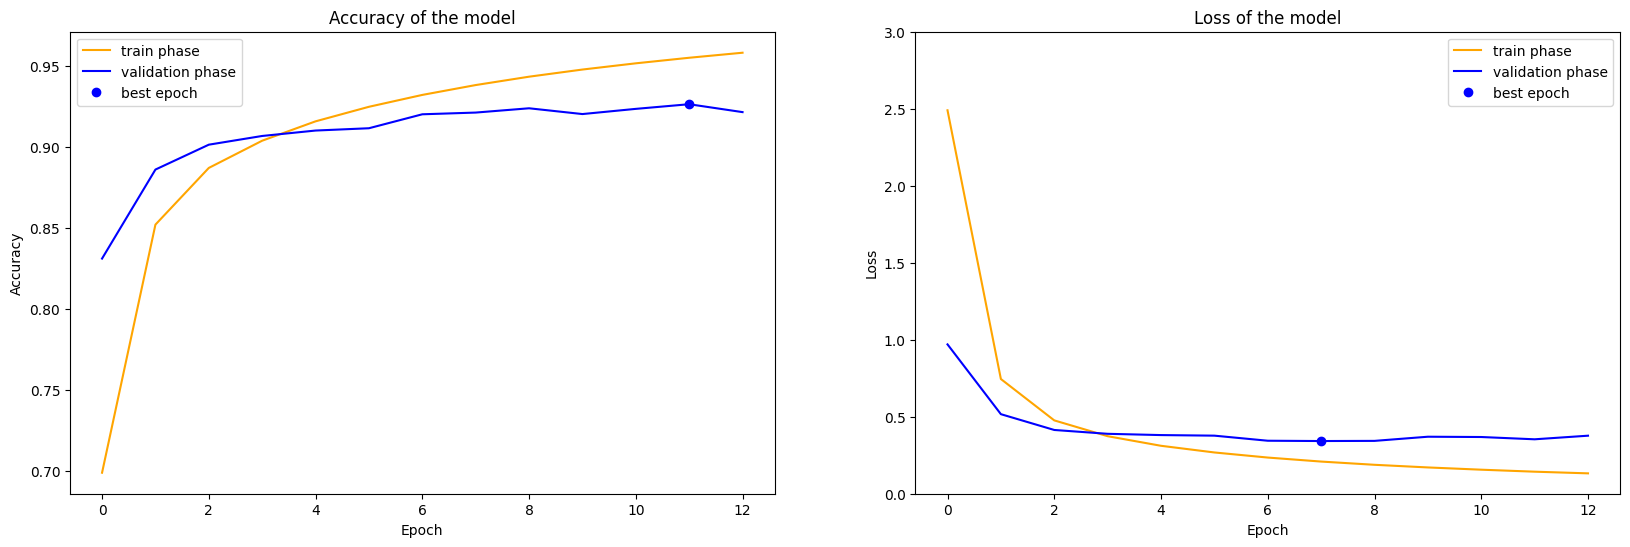

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))

plt.subplot(1,2,1)

x_best_epoch_acc = np.argmax(history.history['val_categorical_accuracy'])
y_best_epoch_acc = history.history['val_categorical_accuracy'][x_best_epoch_acc]
plt.plot(history.history['categorical_accuracy'], label="train phase", color = "orange")
plt.plot(history.history['val_categorical_accuracy'], label="validation phase", color = "blue")
plt.plot(x_best_epoch_acc, y_best_epoch_acc, 'bo', label="best epoch")
plt.title('Accuracy of the model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()


plt.subplot(1,2,2)

x_best_epoch_loss = np.argmin(history.history['val_loss'])
y_best_epoch_loss = history.history['val_loss'][x_best_epoch_loss]
plt.plot(history.history['loss'], label="train phase", color = "orange")
plt.plot(history.history['val_loss'], label="validation phase", color = "blue")
plt.plot(x_best_epoch_loss, y_best_epoch_loss,'bo', label="best epoch")
plt.title('Loss of the model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.ylim([0, 3])
plt.legend()

plt.show()


The **getInitOutputSequences** initialize the matrix of output sequences with the "start" and "end" token. This function is used inside **predictSequences**

**Input parameter**
* **input_sequences**: the sequences that are given in input to the model (shuffled phrases)
* **batch_size**: size of the batch
* **sequence_length**: max length of the sequence
* **sos**: start token (usually is 2)
* **eos**: end token (usually is 3)

**Output parameter**
* **output_sequences**: the matrix that is given to the model and where are saved the prediction token

In [37]:
def getInitOutputSequences(input_sequences, batch_size, sequence_length, sos, eos):
  # Initialize the output sequences with the basic tokens: start token, end token and 0s. (like in input_sequences)
  output_sequences = np.full((batch_size, sequence_length),1, dtype=int)
  output_sequences[:, 0] = sos

  #Complete the array with zeros after the eos
  for i in range(batch_size):
    for j in range(sequence_length):
      if input_sequences[i,j]==eos:
        output_sequences[i,j]=eos
        output_sequences[i,j+1:]=0
  return output_sequences

The **predictSequences** takes in input a batch of shuffled phrases and return a batch of ordered phrases (predicted phrases)

**Input parameter**
* **input_sequences**: batch of shuffled phrases
* **model**: the trained model for performe prediction
* **mask_pad**: batch of padding mask

**Output parameter**
* **output_sequences**: batch of ordered phrases

In [38]:
import numpy as np
import re

def predictSequences(input_sequences, model, mask_pad):
    sos = 3
    eos = 2
    batch_size = input_sequences.shape[0]
    sequence_length = input_sequences.shape[1]
    mask_pad = mask_pad.reshape((batch_size, sequence_length))

    output_sequences = getInitOutputSequences(input_sequences, batch_size, sequence_length, sos, eos)

    # Generate every signle token for each sequence in the batch
    for i in range(1, sequence_length):
        # For each input sequence in the batch predict the next token in the output sequence
        output_probs = model.predict([input_sequences, output_sequences,mask_pad,mask_pad], verbose=0)
        next_token_indices = np.argmax(output_probs[:, i-1, :], axis=1)
        # Add the next token to the output sequence for each input sequence in the batch
        for j in range(batch_size):
            output_sequences[j, i] = next_token_indices[j]

        # When the end token or 0 is generated for all input sequences in the batch then it can stop the loop
        if np.all(next_token_indices == eos) or np.all(next_token_indices == 0):
            break

    return output_sequences

The **cleanData** function takes in input a string and removes all the part that are not useful anymore (like \<string>,\<comma>,ecc). It removes also the useless space.

**Input parameter**
* **data**: string which has to be cleaned

**Output parameter**
* **data**: string cleaned

*Example:*

*input data: "\<start> biological classification is based on how organisms \<comma> are related \<end>"*

*output data: "biological classification is based on how organisms are related"*

In [39]:
def cleanData(data):
  data = data.replace("<comma>",",") #remove the tag <comma>
  data = data.replace("<end>","")    #remove the tag <end>
  data = data.replace("<start>","")  #remove the tag <start>
  if data[0] == " ": #remove the space in front of the string
    data = data[1:]
  if data[-1] == " ":#remove the space at the end of the string
    data = data[:-1]
  data = re.sub(' +', ' ',data) #remove multiple space
  return data

Example of data

In [40]:
random_max_index = 200
num_samples = 5


random_indexes = np.arange(random_max_index)
np.random.shuffle(random_indexes)
random_indexes = random_indexes[:num_samples]
for i in random_indexes:
  #predict
  pred_batch_prova=predictSequences(shuf_test[i:i+1], model, shuf_test_mask[i:i+1])

  #Translate the list of numbers in words
  original_string = detokenizer._TextDetokenizer__detokenize_tokens(orig_test[i])
  pred_batch_string = detokenizer._TextDetokenizer__detokenize_tokens(pred_batch_prova[0])
  shuf_test_string = detokenizer._TextDetokenizer__detokenize_tokens(shuf_test[i])

  #Clean all strings
  shuf_test_string = cleanData(shuf_test_string)
  original_string = cleanData(original_string)
  pred_batch_string = cleanData(pred_batch_string)

  #Print
  print(f"Sample {i}")
  print("orig: " + str(original_string))
  print("shuf: " + str(shuf_test_string))
  print("pred: " + str(pred_batch_string))
  print("score: " + str(score(original_string, pred_batch_string)))
  print()

Sample 8
orig: most people are legally drunk after one or two drinks
shuf: drunk one after two drinks most are legally or people
pred: most people are legally drunk one or two after drinks
score: 0.5660377358490566

Sample 136
orig: cholesterol is a special type of lipid that is called a steroid
shuf: a special cholesterol a steroid is lipid type of called is that
pred: cholesterol is a special type of steroid that is called a lipid
score: 0.5238095238095238

Sample 153
orig: food biotechnology is the use of genetic science to create new products from plants and animals
shuf: new and the products animals science of food use biotechnology from plants create genetic is to
pred: biotechnology is the use of genetic science to create new plants and animals from food products
score: 0.6210526315789474

Sample 77
orig: most people think that sexual harassment involves interpersonal relationships in the workplace
shuf: involves relationships in think the harassment workplace interpersonal that

I calculate the mean score using 3000 samples from the test set

In [42]:
batch_size=50
total_size=3000

#Shuffle the index of test set and take the first 3000 indexes
row, col = np.shape(shuf_test)
index=np.arange(row)
np.random.shuffle(index)
index = index[:total_size]

#Take the ordered and shuffled phrases from test set
shuffled_test_data = shuf_test[index]
shuffled_test_mask_data = shuf_test_mask[index]
x_test_test = orig_test[index]


num_batches=total_size//batch_size
scores=[]

for i in range(0, total_size, batch_size):

  #make a prediction for every batch
  pred_batch=predictSequences(shuffled_test_data[i:i+batch_size], model, shuffled_test_mask_data[i:i+batch_size])
  predict_strings = []
  origins_strings = []
  scores_batch = []

  #Translate every predicted phrase of tokens in string
  for real_test_i in pred_batch:
    predict_string = detokenizer._TextDetokenizer__detokenize_tokens(real_test_i)
    predict_strings.append(cleanData(predict_string))

  #Translate every original phrase of tokens in string
  for origin_test_i in x_test_test[i:i+batch_size]:
    origin_string = detokenizer._TextDetokenizer__detokenize_tokens(origin_test_i)
    origins_strings.append(cleanData(origin_string))

  #Calculate the score of batch
  for j in range(batch_size):
    scores.append(score(origins_strings[j],predict_strings[j]))
    scores_batch.append(score(origins_strings[j],predict_strings[j]))
  print(f"Number batch: {(i//batch_size)+1}/{num_batches}   Score batch: {np.mean(scores_batch)}")

Number batch: 1/60   Score batch: 0.5658228625359277
Number batch: 2/60   Score batch: 0.5099628545782998
Number batch: 3/60   Score batch: 0.5545758542723846
Number batch: 4/60   Score batch: 0.46115271551579284
Number batch: 5/60   Score batch: 0.5629958931274054
Number batch: 6/60   Score batch: 0.4942820613071013
Number batch: 7/60   Score batch: 0.4845846250250577
Number batch: 8/60   Score batch: 0.5794385400605748
Number batch: 9/60   Score batch: 0.5621533048048687
Number batch: 10/60   Score batch: 0.5285699992850826
Number batch: 11/60   Score batch: 0.5057621476525066
Number batch: 12/60   Score batch: 0.5027546989305693
Number batch: 13/60   Score batch: 0.5106276168671099
Number batch: 14/60   Score batch: 0.551002254277642
Number batch: 15/60   Score batch: 0.5065588041343622
Number batch: 16/60   Score batch: 0.45636523583469
Number batch: 17/60   Score batch: 0.5969208104088587
Number batch: 18/60   Score batch: 0.5523369703828491
Number batch: 19/60   Score batch: 0.56

In [44]:
print(f"The mean score with {total_size} is {np.mean(scores)}")

The mean score with 3000 is 0.5237327068611787


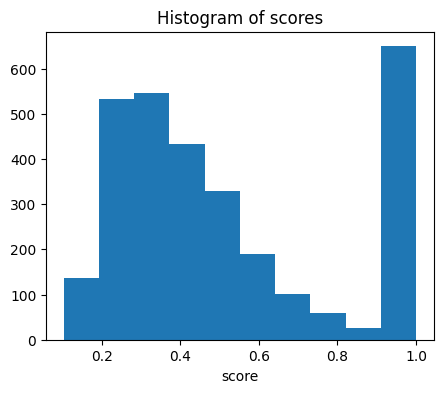

In [46]:
plt.figure(figsize=(5,4))
plt.hist(scores)
plt.title("Histogram of scores")
plt.xlabel("score")
plt.show()

##Conclusion

The sequence reordering task is a typical exercise of NLP. There are several model that can be used in order to achieve the goal. Firstly, I have tried to train model with encoder-decoder approach using LSTM cells but the score was very low.

So I have decided to implement a model with Transformer with different combination of hyperparameter. The score that the model has reached is 0.523 (it is calulated over 3000 samples of the test set)